In [3]:
import pandas as pd 
import numpy as  np 
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Customer Churn.csv')
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

#replacing blanks with 0 as tenure is 0 and no total charges are recorded

In [5]:
df["TotalCharges"] = df["TotalCharges"].replace(" ","0")
df["TotalCharges"] = df["TotalCharges"].astype("float")

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [9]:
df.isnull().sum().sum()

np.int64(0)

In [10]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [13]:
df["customerID"].duplicated().sum()


np.int64(0)

In [15]:
def conv(value):
   if value == 1:
       return "yes"
   else:
       return "no"
df['SeniorCitizen'] = df["SeniorCitizen"].apply(conv)      

#converted 0 and 1 values of senior citizen to yes/no to make it easier to understand

Task was destroyed but it is pending!
task: <Task pending name='Task-200' coro=<_async_in_context.<locals>.run_in_context() done, defined at C:\Users\romas\AppData\Roaming\Python\Python313\site-packages\ipykernel\utils.py:57> wait_for=<Task pending name='Task-201' coro=<Kernel.shell_main() running at C:\Users\romas\AppData\Roaming\Python\Python313\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at C:\Users\romas\AppData\Roaming\Python\Python313\site-packages\zmq\eventloop\zmqstream.py:563]>
C:\Users\romas\AppData\Roaming\Python\Python313\site-packages\pandas\core\nanops.py:80: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  obj_iter = itertools.chain(args, kwargs.values())
Task was destroyed but it is pending!
task: <Task pending name='Task-201' coro=<Kernel.shell_main() running at C:\Users\romas\AppData\Roaming\Python\Python313\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]>


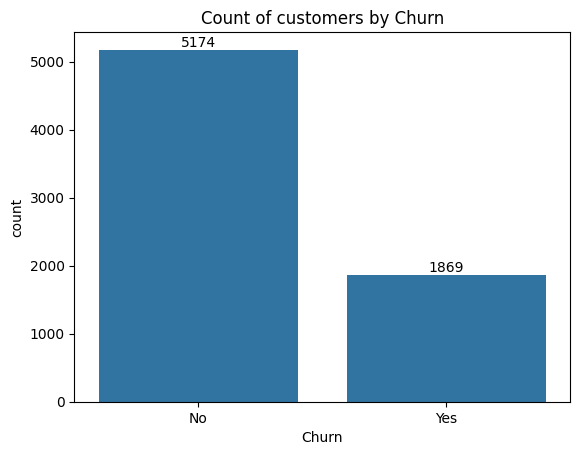

In [29]:
ax = sns.countplot( x = 'Churn',data = df)

ax.bar_label(ax.containers[0])
plt.title("Count of customers by Churn")
plt.show()

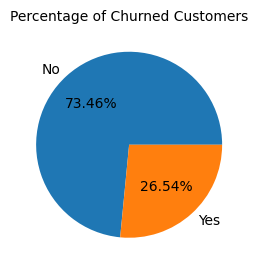

In [32]:
plt.figure(figsize = (3,4) ) 
gb = df.groupby("Churn").agg({'Churn':"count"})
plt.pie(gb['Churn'], labels = gb.index, autopct = "%1.2f%%" )
plt.title("Percentage of Churned Customers", fontsize = 10)
plt.show()

#from the given pie chart we can conclude that 26.54% of our customers have churned out
#not Let's explore the reason behind it.

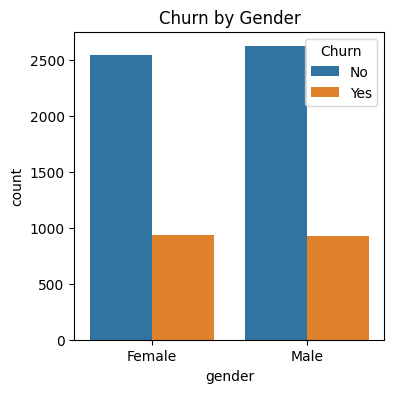

In [41]:
plt. figure(figsize = (4,4))
sns.countplot(x = "gender", data = df, hue = "Churn")
plt.title("Churn by Gender")
plt.show()

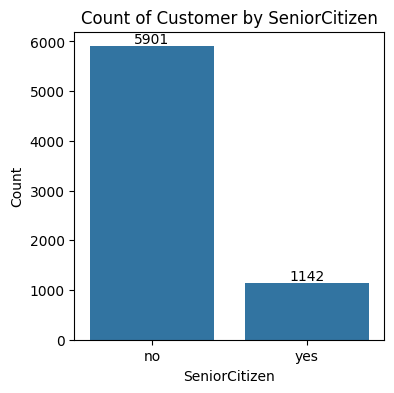

In [59]:
plt.figure(figsize=(4,4))

ax = sns.countplot(x="SeniorCitizen", data=df)

# Add count labels
for container in ax.containers:
    ax.bar_label(container)

plt.title("Count of Customer by SeniorCitizen")
plt.xlabel("SeniorCitizen")
plt.ylabel("Count")

plt.show()

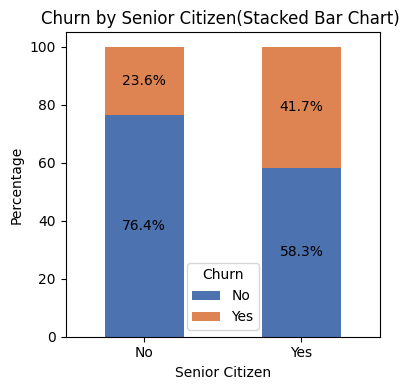

In [52]:
import pandas as pd
import matplotlib.pyplot as plt

# Create percentage table
churn_pct = pd.crosstab(
    df['SeniorCitizen'],
    df['Churn'],
    normalize='index'
) * 100

# Plot
ax = churn_pct.plot(
    kind='bar',
    stacked=True,
    figsize=(4,4),
    color=["#4C72B0", "#DD8452"]
)

# Add percentage labels
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%',
        label_type='center',
        fontsize=10,
        color='black'
    )

plt.title("Churn by Senior Citizen(Stacked Bar Chart) ")
plt.xlabel("Senior Citizen")
plt.ylabel("Percentage")
plt.xticks([0,1], ['No', 'Yes'], rotation=0)
plt.legend(title="Churn")
plt.tight_layout()
plt.show()

#comparative a greater percentage of people in senior citizen category have churned

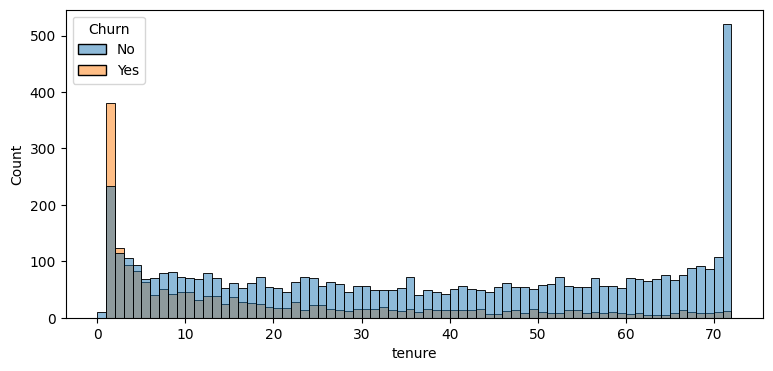

In [65]:
plt.figure(figsize = (9,4))
sns.histplot(x = "tenure", data = df,  bins = 72, hue ="Churn")
plt.show()

#people who have used our services for a long time have stayed and people who have used our services #1 or 2 months have churned

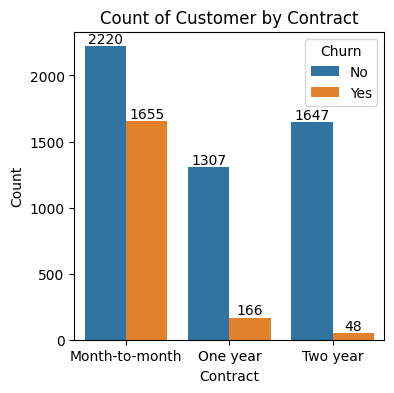

In [68]:
plt.figure(figsize=(4,4))

ax = sns.countplot(x="Contract", data=df, hue = "Churn")

# Add count labels
for container in ax.containers:
    ax.bar_label(container)

plt.title("Count of Customer by Contract")
plt.xlabel("Contract")
plt.ylabel("Count")

plt.show()

# people who have month to month contract are likely to churn then from those who have one or two years contract

In [70]:
df.coloum.values
 arrays(['customerID','gender','SeniorCitizen', 'Partner','Dependents','tenure','PhoneService','Multiplelines','InternetService','onlineSecurity','onlineBackup','DeviceProtection','TechSupport','StreamingTV','SteamingMovies','Contract','PaperlessBilling','PaymentMethod','MonthlyCharges','TotalCharges','Churn'],dtype=object)

IndentationError: unexpected indent (1755799218.py, line 2)

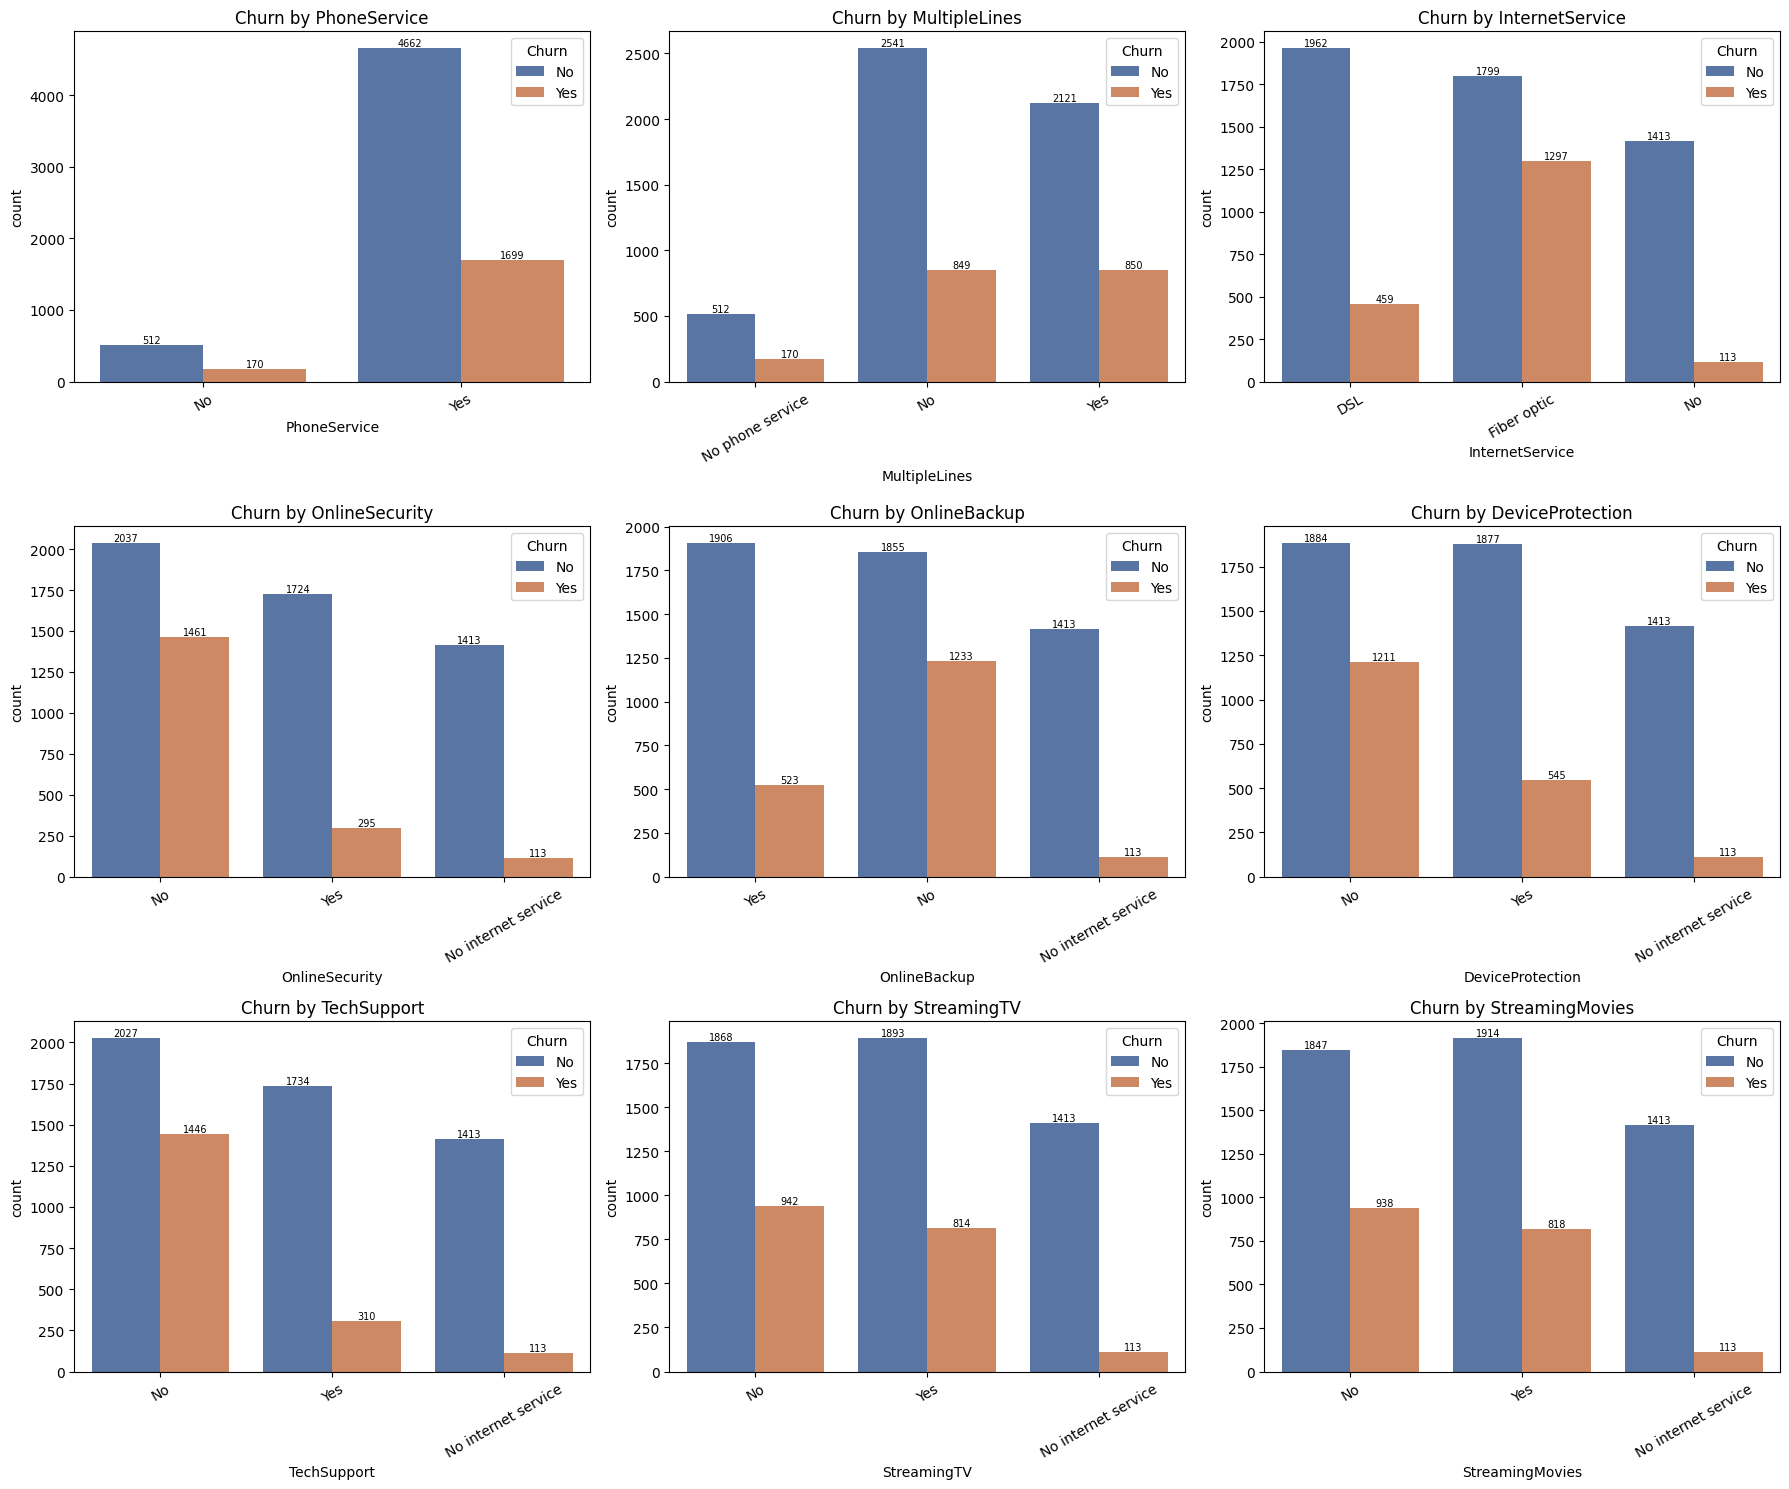

In [74]:
import matplotlib.pyplot as plt
import seaborn as sns
columns = [
    'PhoneService',
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
]

fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()

for i, col in enumerate(columns):
    sns.countplot(
        x=col,
        data=df,
        hue='Churn',
        ax=axes[i],
        palette="deep"
    )

    axes[i].set_title(f"Churn by {col}")
    axes[i].tick_params(axis='x', rotation=30)

    for container in axes[i].containers:
        axes[i].bar_label(container, fontsize=7)

plt.tight_layout()
plt.show()


#Churn is significantly higher among customers using Fiber Optic Internet. Customers without Online Security, Tech Support, Online Backup, and Device Protection are more likely to leave the service. Customers with No Internet Service show the lowest churn, suggesting that additional service features help improve customer retention.

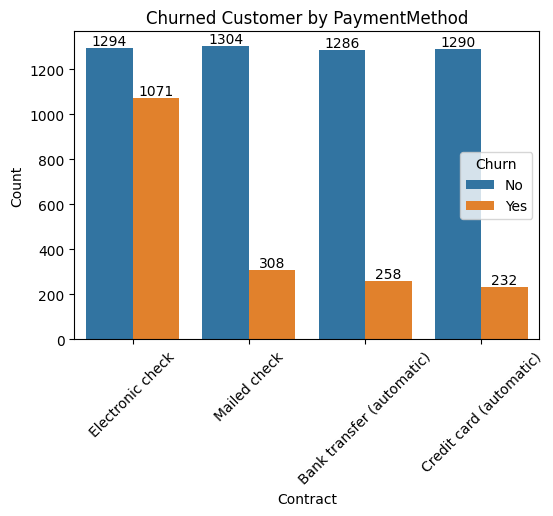

In [77]:
plt.figure(figsize=(6,4))

ax = sns.countplot(x="PaymentMethod", data=df, hue = "Churn")

# Add count labels
for container in ax.containers:
    ax.bar_label(container)

plt.title("Churned Customer by PaymentMethod")
plt.xlabel("Contract")
plt.ylabel("Count")
plt.xticks(rotation = 45)
plt.show()

#customer is likely to churn when he is using electronics check as a payment method.